In [5]:
# load libraries and get word files
import os
import re
import nltk
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# download nltk data
nltk.download('gutenberg', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)
nltk.download('averaged_perceptron_tagger_eng', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('sentiwordnet', quiet=True)

# make folders
os.makedirs("../figures", exist_ok=True)
os.makedirs("../data/processed", exist_ok=True)

print("setup done")

setup done


In [6]:
# task 1: count character names in book and in talking parts
import os
import re
import urllib.request
import pandas as pd
import nltk

# get book text from nltk or gutenberg
raw_text = None

try:
    from nltk.corpus import gutenberg
    raw_text = gutenberg.raw('austen-pride.txt')
    print("loaded from nltk")
except Exception:
    pass

if not raw_text:
    local_path = "../data/raw/pride_and_prejudice.txt"
    os.makedirs("../data/raw", exist_ok=True)

    if not os.path.exists(local_path):
        print("downloading book from gutenberg")
        url = "https://www.gutenberg.org/files/1342/1342-0.txt"
        urllib.request.urlretrieve(url, local_path)

    with open(local_path, "r", encoding="utf-8") as f:
        raw_text = f.read()
    print("loaded from file")

# names and nicknames for each person
CHARACTER_ALIASES = {
    "Elizabeth Bennet": [r"\bElizabeth\b", r"\bLizzy\b", r"\bMiss Bennet\b"],
    "Fitzwilliam Darcy": [r"\bMr\. Darcy\b", r"\bDarcy\b"],
    "Jane Bennet": [r"\bJane\b", r"\bMiss Jane Bennet\b"],
    "Mr. Bennet": [r"\bMr\. Bennet\b"],
    "Mrs. Bennet": [r"\bMrs\. Bennet\b"],
    "Charles Bingley": [r"\bMr\. Bingley\b", r"\bBingley\b"],
    "George Wickham": [r"\bMr\. Wickham\b", r"\bWickham\b"],
    "William Collins": [r"\bMr\. Collins\b", r"\bCollins\b"],
    "Lydia Bennet": [r"\bLydia\b"],
    "Lady Catherine de Bourgh": [r"\bLady Catherine\b", r"\bLady Catherine de Bourgh\b"]
}

# find spoken lines in quotes
dialogue_pattern = r'["“](.*?)["”]'
dialogue_statements = re.findall(dialogue_pattern, raw_text, flags=re.DOTALL)
combined_dialogue = " ".join(dialogue_statements)

# count names in whole book and inside talking parts
results = []
for character, aliases in CHARACTER_ALIASES.items():
    combined_pattern = re.compile("|".join(aliases), flags=re.IGNORECASE)
    total_occurrences = len(combined_pattern.findall(raw_text))
    dialogue_citations = len(combined_pattern.findall(combined_dialogue))

    results.append({
        "Character": character,
        "Total Occurrences": total_occurrences,
        "Dialogue Citations": dialogue_citations
    })

# make table and sort by most mentions
df_task1 = pd.DataFrame(results)
df_task1["Rank (Occurrences)"] = df_task1["Total Occurrences"].rank(ascending=False, method="min").astype(int)
df_task1["Rank (Citations)"] = df_task1["Dialogue Citations"].rank(ascending=False, method="min").astype(int)
df_task1 = df_task1.sort_values(by="Total Occurrences", ascending=False).reset_index(drop=True)

# save table to csv
df_task1.to_csv("../data/processed/task1_character_importance.csv", index=False)

# show table
df_task1

loaded from file


,Character,Total Occurrences,Dialogue Citations,Rank (Occurrences),Rank (Citations)
0,Elizabeth Bennet,801,145,1,2
1,Fitzwilliam Darcy,430,159,2,1
2,Charles Bingley,310,93,3,3
3,Jane Bennet,302,71,4,5
4,George Wickham,200,90,5,4
5,William Collins,190,52,6,7
6,Lydia Bennet,176,56,7,6
7,Mrs. Bennet,140,6,8,10
8,Lady Catherine de Bourgh,106,35,9,8
9,Mr. Bennet,86,18,10,9


In [7]:
# task 2: pull out spoken lines and count parts of speech
import re
import pandas as pd
import nltk
from nltk.tokenize import word_tokenize
from nltk import pos_tag

# names to look for
CHARACTER_PATTERNS = {
    "Elizabeth Bennet": r"(?:Elizabeth|Lizzy|Miss Bennet)",
    "Fitzwilliam Darcy": r"(?:Mr\.\s+Darcy|Darcy)",
    "Jane Bennet": r"(?:Miss Jane Bennet|Jane)",
    "Mr. Bennet": r"Mr\.\s+Bennet",
    "Mrs. Bennet": r"Mrs\.\s+Bennet",
    "Charles Bingley": r"(?:Mr\.\s+Bingley|Bingley)",
    "George Wickham": r"(?:Mr\.\s+Wickham|Wickham)",
    "William Collins": r"(?:Mr\.\s+Collins|Collins)",
    "Lydia Bennet": r"Lydia",
    "Lady Catherine de Bourgh": r"(?:Lady Catherine de Bourgh|Lady Catherine)"
}

# words for speaking
speech_verbs = r"(?:said|cried|replied|added|exclaimed|remarked|observed|continued|asked|returned|answered|resumed|began|inquired)"

# read text piece by piece and match quotes to speaker
paragraphs = raw_text.split("\n\n")
character_dialogues = {char: [] for char in CHARACTER_PATTERNS}

for para in paragraphs:
    para_clean = " ".join(para.split())
    quotes = re.findall(r'["“](.*?)["”]', para_clean)
    if not quotes:
        continue

    for char, pat in CHARACTER_PATTERNS.items():
        attr_regex = rf"(?:{speech_verbs}\s+{pat}|{pat}\s+{speech_verbs})"
        if re.search(attr_regex, para_clean, flags=re.IGNORECASE):
            for q in quotes:
                cleaned_q = q.strip()
                if len(cleaned_q) > 3:
                    character_dialogues[char].append(cleaned_q)

# count total words and tag nouns verbs and adjectives
task2_records = []
character_corpora_tokens = {}

for character, quotes in character_dialogues.items():
    unique_quotes = list(set(quotes))
    character_dialogues[character] = unique_quotes

    full_speech = " ".join(unique_quotes)
    tokens = [w.lower() for w in word_tokenize(full_speech) if w.isalnum()]
    character_corpora_tokens[character] = tokens

    total_tokens = len(tokens)
    vocab_size = len(set(tokens))

    pos_tags = pos_tag(tokens) if total_tokens > 0 else []

    num_nouns = sum(1 for _, tag in pos_tags if tag.startswith('NN'))
    num_verbs = sum(1 for _, tag in pos_tags if tag.startswith('VB'))
    num_adjectives = sum(1 for _, tag in pos_tags if tag.startswith('JJ'))
    num_adverbs = sum(1 for _, tag in pos_tags if tag.startswith('RB'))

    ttr = round(vocab_size / total_tokens, 4) if total_tokens > 0 else 0

    task2_records.append({
        "Character": character,
        "Total Utterances": len(unique_quotes),
        "Total Tokens": total_tokens,
        "Vocabulary Size": vocab_size,
        "Nouns": num_nouns,
        "Verbs": num_verbs,
        "Adjectives": num_adjectives,
        "Adverbs": num_adverbs,
        "Type-Token Ratio (TTR)": ttr
    })

# make summary table and save to csv
df_task2 = pd.DataFrame(task2_records).sort_values(by="Total Tokens", ascending=False).reset_index(drop=True)
df_task2.to_csv("data/processed/task2_character_lexical_profiles.csv", index=False)

# show table
df_task2

,Character,Total Utterances,Total Tokens,Vocabulary Size,Nouns,Verbs,Adjectives,Adverbs,Type-Token Ratio (TTR)
0,Elizabeth Bennet,167,3113,830,551,647,268,239,0.2666
1,Jane Bennet,48,1446,485,234,321,124,121,0.3354
2,Mrs. Bennet,37,901,325,144,196,79,88,0.3607
3,Fitzwilliam Darcy,35,701,333,140,151,59,63,0.4750
4,Lydia Bennet,18,552,232,99,127,32,55,0.4203
5,William Collins,11,442,228,73,78,42,46,0.5158
6,Charles Bingley,24,436,213,79,86,40,45,0.4885
7,George Wickham,16,368,186,60,73,34,36,0.5054
8,Mr. Bennet,18,290,170,48,61,20,22,0.5862
9,Lady Catherine de Bourgh,6,212,141,32,50,27,24,0.6651


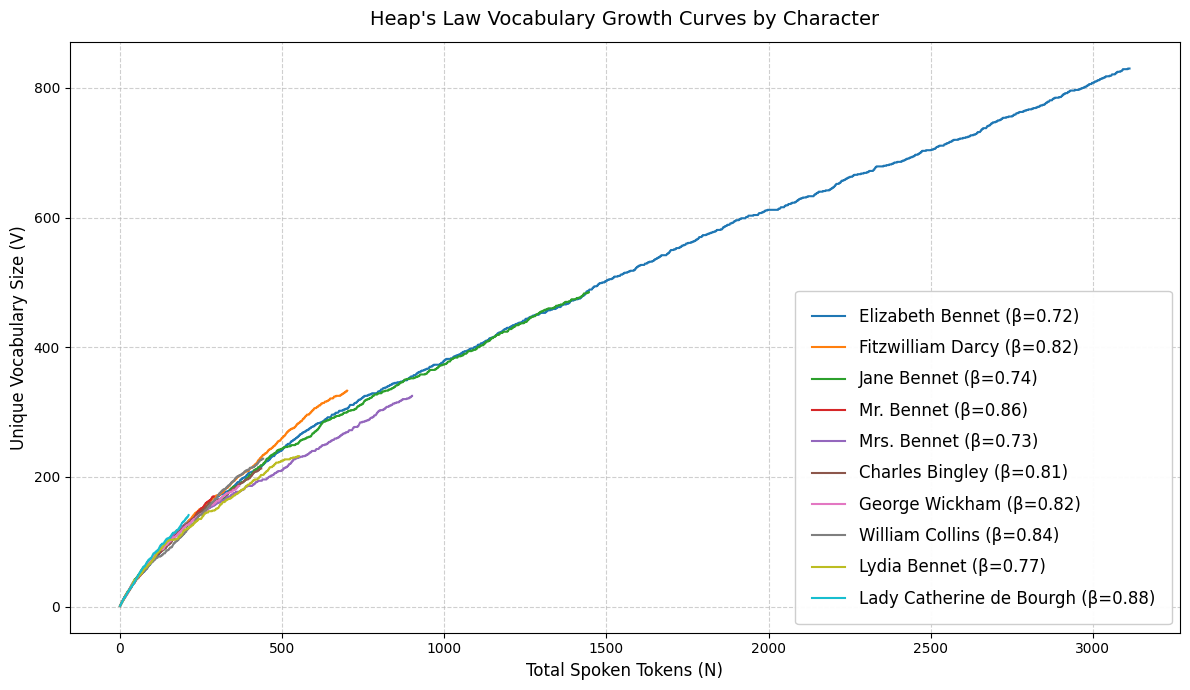

task 3 summary table:


,Character,Total Words (N),Total Vocab (V),Heap's K,Heap's Beta (Growth),R-squared,Adjusted R-squared
0,Elizabeth Bennet,3113,830,2.602,0.7196,0.9966,0.9966
1,Jane Bennet,1446,485,2.277,0.7430,0.9933,0.9933
2,Mrs. Bennet,901,325,2.299,0.7337,0.9878,0.9878
3,Fitzwilliam Darcy,701,333,1.594,0.8210,0.9982,0.9982
4,Lydia Bennet,552,232,1.876,0.7749,0.9906,0.9906
5,William Collins,442,228,1.423,0.8354,0.9972,0.9972
6,Charles Bingley,436,213,1.622,0.8116,0.9920,0.9920
7,George Wickham,368,186,1.584,0.8185,0.9893,0.9893
8,Mr. Bennet,290,170,1.355,0.8555,0.9981,0.9981
9,Lady Catherine de Bourgh,212,141,1.281,0.8845,0.9918,0.9918


In [8]:
# task 3: fit heaps law curve and count new words over time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score

# formula for heaps law
def heaps_law(N, K, beta):
    return K * (N ** beta)

# calculate word growth for each person
heaps_results = []
growth_curves = {}

plt.figure(figsize=(12, 7))

for character, tokens in character_corpora_tokens.items():
    if len(tokens) < 100:
        continue  # skip people with too few words

    # count unique words word by word
    seen_vocab = set()
    vocab_growth = []

    for word in tokens:
        seen_vocab.add(word)
        vocab_growth.append(len(seen_vocab))

    N_steps = np.arange(1, len(tokens) + 1)
    V_steps = np.array(vocab_growth)
    growth_curves[character] = (N_steps, V_steps)

    # fit line on log values
    log_N = np.log(N_steps)
    log_V = np.log(V_steps)

    poly = np.polyfit(log_N, log_V, 1)
    beta = poly[0]
    K = np.exp(poly[1])

    # predict values using heaps law
    V_pred = heaps_law(N_steps, K, beta)

    # check fit score
    r2 = r2_score(V_steps, V_pred)
    n = len(N_steps)
    p = 1
    adj_r2 = 1 - ((1 - r2) * (n - 1)) / (n - p - 1)

    heaps_results.append({
        "Character": character,
        "Total Words (N)": len(tokens),
        "Total Vocab (V)": len(seen_vocab),
        "Heap's K": round(K, 3),
        "Heap's Beta (Growth)": round(beta, 4),
        "R-squared": round(r2, 4),
        "Adjusted R-squared": round(adj_r2, 4)
    })

    # add line to plot
    plt.plot(N_steps, V_steps, label=f"{character} (β={beta:.2f})")

# plot settings
plt.title("Heap's Law Vocabulary Growth Curves by Character", fontsize=14, pad=12)
plt.xlabel("Total Spoken Tokens (N)", fontsize=12)
plt.ylabel("Unique Vocabulary Size (V)", fontsize=12)
plt.legend(
    loc="lower right",
    fontsize=12,
    markerscale=2,
    borderpad=1.0,
    labelspacing=0.8,
    framealpha=0.95,
)
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()

# save plot
plt.savefig("heaps_law_plot.png", dpi=300, bbox_inches="tight")
plt.show()

# make table and save to csv
df_task3 = pd.DataFrame(heaps_results)
df_task3 = df_task3.sort_values(by="Total Words (N)", ascending=False).reset_index(drop=True)

df_task3.to_csv("../data/processed/task3_heaps_law_summary.csv", index=False)

print("task 3 summary table:")
df_task3

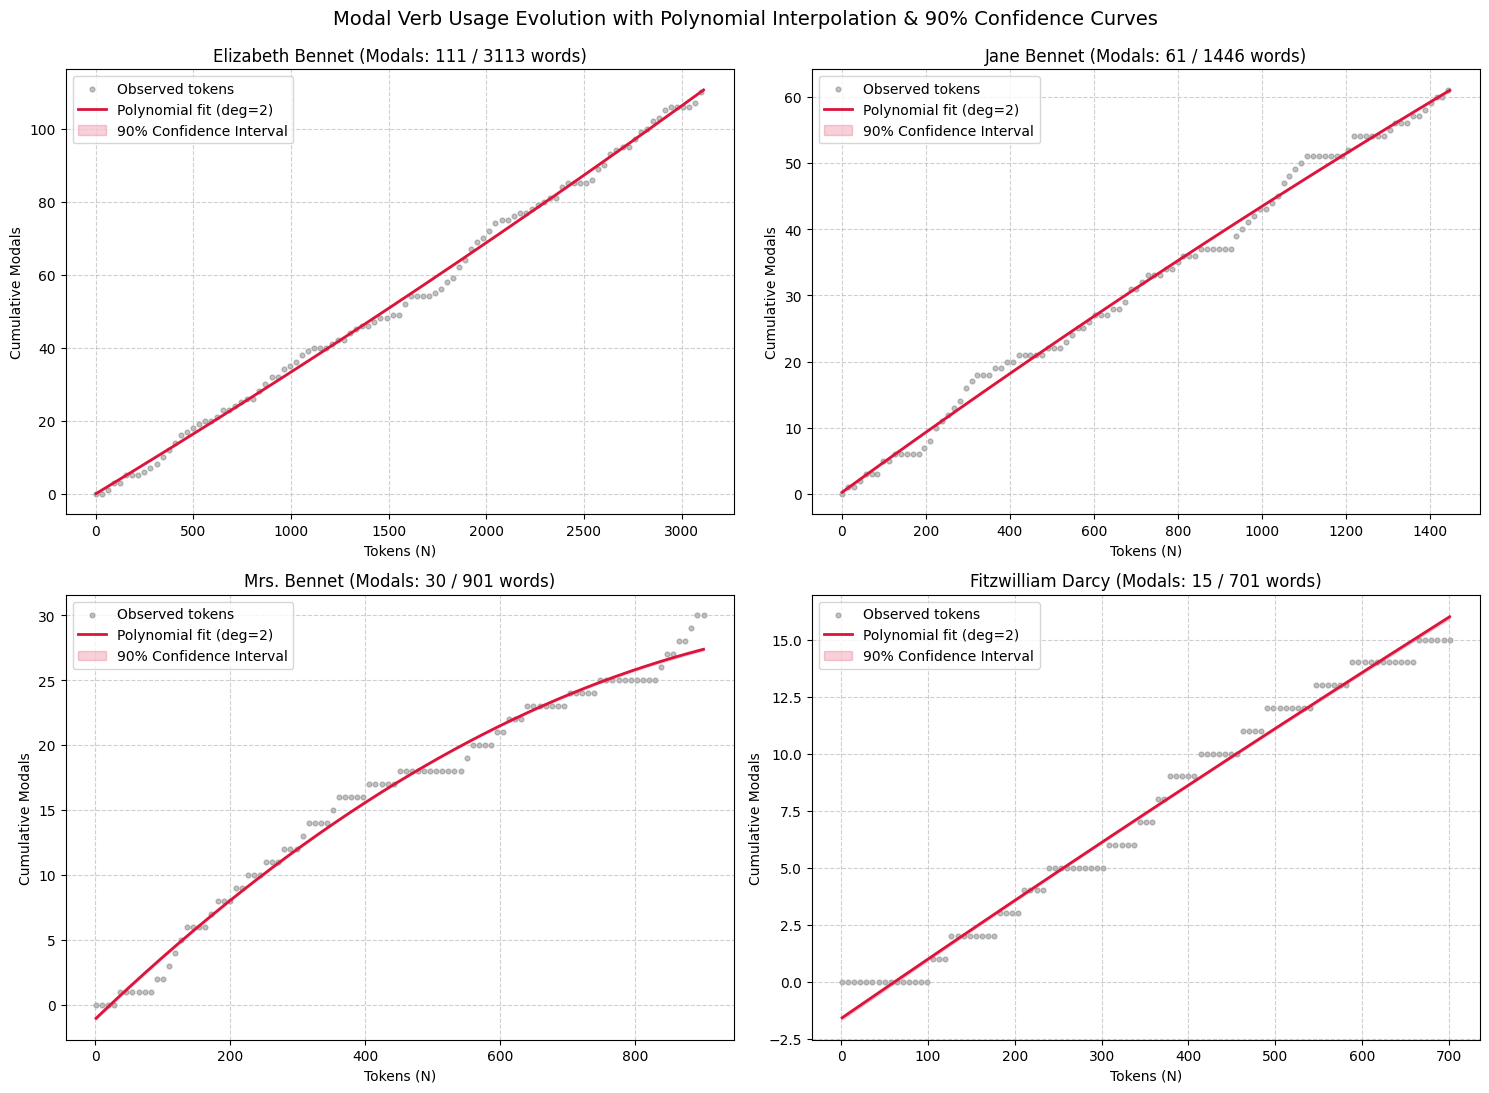

task 4 summary table:


,Character,Total Tokens,Total Modals,Modal Density (%),should,shall,must,might,will,can,may,could,would
0,Elizabeth Bennet,3113,111,3.57,8,9,24,1,21,22,6,9,11
1,Jane Bennet,1446,61,4.22,3,2,8,3,14,12,7,7,5
2,Mrs. Bennet,901,30,3.33,4,5,1,0,6,7,3,2,2
3,Fitzwilliam Darcy,701,15,2.14,2,0,3,2,0,5,1,1,1
4,Lydia Bennet,552,17,3.08,4,2,1,1,1,3,1,0,4
5,William Collins,442,21,4.75,3,2,2,1,1,4,3,2,3
6,Charles Bingley,436,15,3.44,1,0,2,0,4,1,3,1,3
7,George Wickham,368,10,2.72,2,0,0,0,1,2,2,1,2
8,Mr. Bennet,290,13,4.48,3,0,0,0,3,1,5,0,1
9,Lady Catherine de Bourgh,212,4,1.89,0,0,0,0,0,2,0,0,2


In [9]:
# task 4: count helping verbs and plot how they grow over time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# words to look for
MODAL_VERBS = {"can", "may", "must", "shall", "will", "could", "might", "should", "would"}

modal_summary_records = []
modal_evolution_data = {}

# count modal verbs for each character
for character, tokens in character_corpora_tokens.items():
    if len(tokens) < 100:
        continue

    # count running total
    cum_modals = []
    modal_count = 0
    modal_breakdown = {m: 0 for m in MODAL_VERBS}

    for word in tokens:
        if word in MODAL_VERBS:
            modal_count += 1
            modal_breakdown[word] += 1
        cum_modals.append(modal_count)

    modal_evolution_data[character] = {
        "tokens": np.arange(1, len(tokens) + 1),
        "cum_modals": np.array(cum_modals)
    }

    rec = {
        "Character": character,
        "Total Tokens": len(tokens),
        "Total Modals": modal_count,
        "Modal Density (%)": round((modal_count / len(tokens)) * 100, 2)
    }
    rec.update(modal_breakdown)
    modal_summary_records.append(rec)

# make 4 subplots for the top speakers
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 11), sharex=False)
axes = axes.flatten()

# pick 4 characters with the most words
top_4_characters = [r["Character"] for r in sorted(modal_summary_records, key=lambda x: x["Total Tokens"], reverse=True)[:4]]

for idx, character in enumerate(top_4_characters):
    ax = axes[idx]
    x = modal_evolution_data[character]["tokens"]
    y = modal_evolution_data[character]["cum_modals"]

    # fit a curve to the points
    poly_coeffs, cov_matrix = np.polyfit(x, y, deg=2, cov=True)
    poly_func = np.poly1d(poly_coeffs)
    y_pred = poly_func(x)

    # calculate confidence area
    residuals = y - y_pred
    n = len(x)
    dof = max(1, n - 3)
    s_err = np.sqrt(np.sum(residuals**2) / dof)

    t_val = stats.t.ppf(0.95, dof)
    conf_interval = t_val * s_err * np.sqrt(1/n + (x - np.mean(x))**2 / np.sum((x - np.mean(x))**2))

    # plot dots and fitted line
    ax.scatter(x[::max(1, len(x)//100)], y[::max(1, len(y)//100)], color="dimgray", alpha=0.4, s=12, label="Observed tokens")
    ax.plot(x, y_pred, color="crimson", lw=2, label="Polynomial fit (deg=2)")
    ax.fill_between(x, y_pred - conf_interval, y_pred + conf_interval, color="crimson", alpha=0.2, label="90% Confidence Interval")

    ax.set_title(f"{character} (Modals: {y[-1]} / {x[-1]} words)", fontsize=12)
    ax.set_xlabel("Tokens (N)")
    ax.set_ylabel("Cumulative Modals")
    ax.grid(True, linestyle="--", alpha=0.6)
    ax.legend(loc="upper left")

plt.suptitle("Modal Verb Usage Evolution with Polynomial Interpolation & 90% Confidence Curves", fontsize=14, y=0.99)
plt.tight_layout()
plt.savefig("../figures/task4_modal_verbs_polyfit.png", dpi=300)
plt.show()

# save table to csv
df_task4 = pd.DataFrame(modal_summary_records)
df_task4 = df_task4.sort_values(by="Total Tokens", ascending=False).reset_index(drop=True)
df_task4.to_csv("../data/processed/task4_modal_verbs_distribution.csv", index=False)

print("task 4 summary table:")
df_task4

top 5 words:
  - 'elizabeth': 643
  - 'could': 529
  - 'would': 482
  - 'darcy': 424
  - 'said': 406


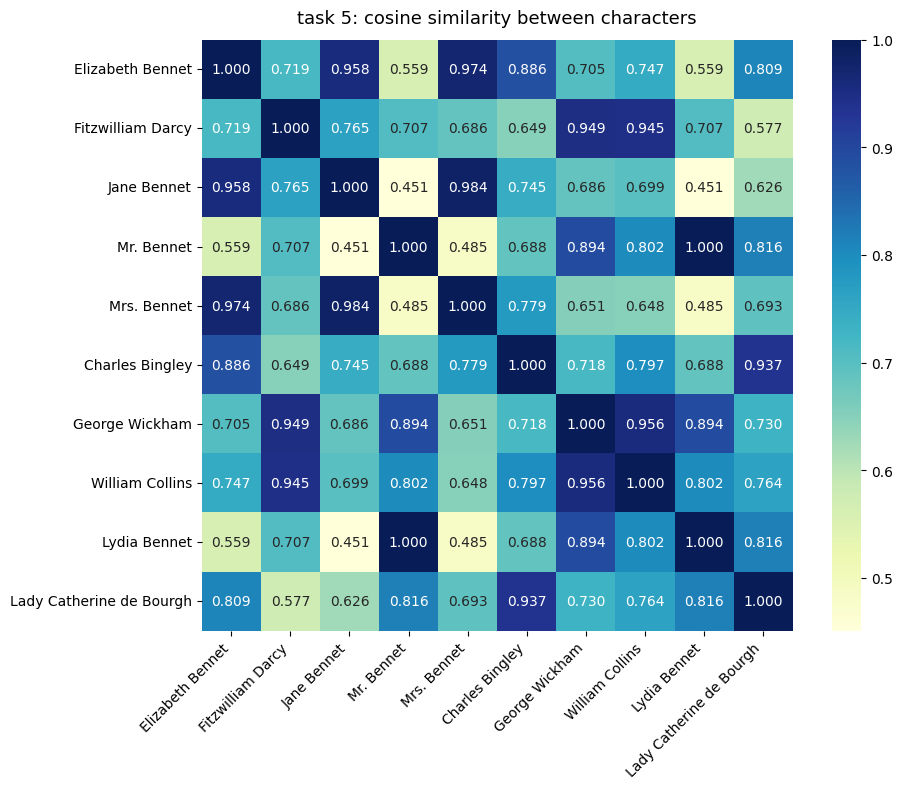


word count table:


,elizabeth,could,would,darcy,said
Elizabeth Bennet,0,9,11,13,4
Fitzwilliam Darcy,0,1,1,0,0
Jane Bennet,0,7,5,7,0
Mr. Bennet,0,0,1,0,0
Mrs. Bennet,0,2,2,3,0
Charles Bingley,1,1,3,2,2
George Wickham,0,1,2,0,0
William Collins,0,2,3,0,1
Lydia Bennet,0,0,4,0,0
Lady Catherine de Bourgh,0,0,2,1,1



similarity table:


,Elizabeth Bennet,Fitzwilliam Darcy,Jane Bennet,Mr. Bennet,Mrs. Bennet,Charles Bingley,George Wickham,William Collins,Lydia Bennet,Lady Catherine de Bourgh
Elizabeth Bennet,1.000000,0.718885,0.957940,0.559161,0.973974,0.886301,0.704727,0.747211,0.559161,0.809345
Fitzwilliam Darcy,0.718885,1.000000,0.765092,0.707107,0.685994,0.648886,0.948683,0.944911,0.707107,0.577350
Jane Bennet,0.957940,0.765092,1.000000,0.450835,0.984092,0.744686,0.685506,0.698846,0.450835,0.625779
Mr. Bennet,0.559161,0.707107,0.450835,1.000000,0.485071,0.688247,0.894427,0.801784,1.000000,0.816497
Mrs. Bennet,0.973974,0.685994,0.984092,0.485071,1.000000,0.778981,0.650791,0.648204,0.485071,0.693103
Charles Bingley,0.886301,0.648886,0.744686,0.688247,0.778981,1.000000,0.718185,0.797081,0.688247,0.936586
George Wickham,0.704727,0.948683,0.685506,0.894427,0.650791,0.718185,1.000000,0.956183,0.894427,0.730297
William Collins,0.747211,0.944911,0.698846,0.801784,0.648204,0.797081,0.956183,1.000000,0.801784,0.763763
Lydia Bennet,0.559161,0.707107,0.450835,1.000000,0.485071,0.688247,0.894427,0.801784,1.000000,0.816497
Lady Catherine de Bourgh,0.809345,0.577350,0.625779,0.816497,0.693103,0.936586,0.730297,0.763763,0.816497,1.000000


In [10]:
# task 5: find top 5 words and compare characters with cosine similarity
import re
from collections import Counter
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# stop words list
stop_words = set(stopwords.words('english'))

# clean whole book and remove stop words
cleaned_book_tokens = [
    w.lower() for w in word_tokenize(raw_text)
    if re.match(r'^[a-zA-Z]+$', w) and len(w) >= 2 and w.lower() not in stop_words
]

# find top 5 most common words
top_5_frequent = Counter(cleaned_book_tokens).most_common(5)
top_5_tokens = [word for word, count in top_5_frequent]
print("top 5 words:")
for word, count in top_5_frequent:
    print(f"  - '{word}': {count}")

# count how many times each character says these 5 words
character_names = list(character_corpora_tokens.keys())
vectors_5d = []

for char in character_names:
    tokens = character_corpora_tokens[char]
    counts = Counter(tokens)
    vec = [counts.get(token, 0) for token in top_5_tokens]
    vectors_5d.append(vec)

# table of word counts
df_5d_vectors = pd.DataFrame(vectors_5d, index=character_names, columns=top_5_tokens)

# calculate similarity between all pairs
cosine_sim_matrix = cosine_similarity(df_5d_vectors)
cosine_sim_matrix = np.nan_to_num(cosine_sim_matrix)

df_task5_matrix = pd.DataFrame(cosine_sim_matrix, index=character_names, columns=character_names)

# save tables to csv
df_5d_vectors.to_csv("data/processed/task5_character_5d_vectors.csv")
df_task5_matrix.to_csv("data/processed/task5_pairwise_cosine_similarity.csv")

# plot similarity heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df_task5_matrix, annot=True, cmap="YlGnBu", fmt=".3f", cbar=True, square=True)
plt.title("task 5: cosine similarity between characters", fontsize=13, pad=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("figures/task5_cosine_similarity_heatmap.png", dpi=300)
plt.show()

print("\nword count table:")
display(df_5d_vectors)

print("\nsimilarity table:")
display(df_task5_matrix)

topic 1: dear, lizzy, know, never, tell, bingley, go, darcy, married, always
topic 2: giving, even, catherine, letter, clear, pray, remarkably, give, else, expect
topic 3: may, think, us, forster, kitty, let, sure, upon, soon, make
topic 4: hope, may, think, certainly, cannot, know, nothing, make, man, certain
topic 5: darcy, good, know, think, indeed, make, cannot, never, oh, really


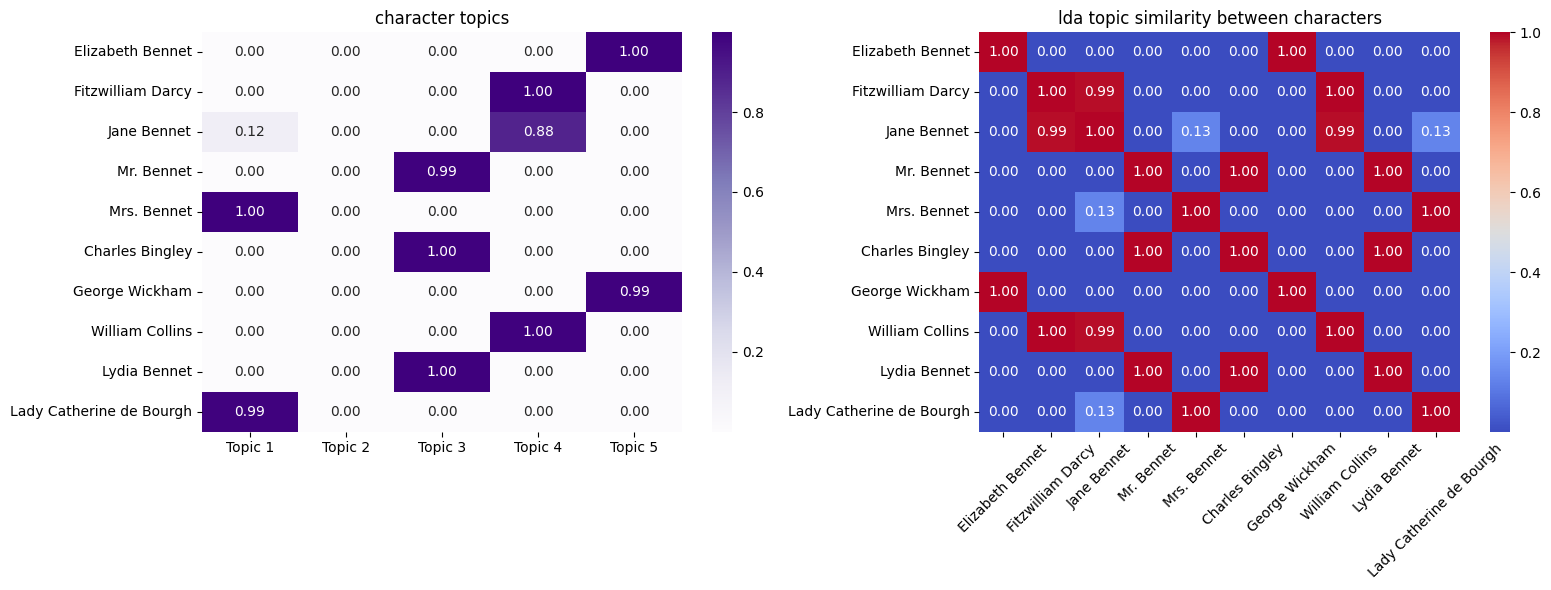


top words table:


,Topic,Top 10 Keywords
0,Topic 1,"dear, lizzy, know, never, tell, bingley, go, d..."
1,Topic 2,"giving, even, catherine, letter, clear, pray, ..."
2,Topic 3,"may, think, us, forster, kitty, let, sure, upo..."
3,Topic 4,"hope, may, think, certainly, cannot, know, not..."
4,Topic 5,"darcy, good, know, think, indeed, make, cannot..."



similarity table:


,Elizabeth Bennet,Fitzwilliam Darcy,Jane Bennet,Mr. Bennet,Mrs. Bennet,Charles Bingley,George Wickham,William Collins,Lydia Bennet,Lady Catherine de Bourgh
Elizabeth Bennet,1.000000,0.000840,0.000586,0.001811,0.000748,0.001412,0.999997,0.001336,0.001079,0.002325
Fitzwilliam Darcy,0.000840,1.000000,0.991635,0.002302,0.001241,0.001909,0.002059,1.000000,0.001575,0.002816
Jane Bennet,0.000586,0.991635,1.000000,0.002227,0.130305,0.001787,0.001950,0.991698,0.001414,0.131864
Mr. Bennet,0.001811,0.002302,0.002227,1.000000,0.002211,1.000000,0.003026,0.002799,0.999999,0.003796
Mrs. Bennet,0.000748,0.001241,0.130305,0.002211,1.000000,0.001815,0.001962,0.001737,0.001489,0.999995
Charles Bingley,0.001412,0.001909,0.001787,1.000000,0.001815,1.000000,0.002626,0.002405,1.000000,0.003398
George Wickham,0.999997,0.002059,0.001950,0.003026,0.001962,0.002626,1.000000,0.002556,0.002291,0.003544
William Collins,0.001336,1.000000,0.991698,0.002799,0.001737,0.002405,0.002556,1.000000,0.002071,0.003314
Lydia Bennet,0.001079,0.001575,0.001414,0.999999,0.001489,1.000000,0.002291,0.002071,1.000000,0.003070
Lady Catherine de Bourgh,0.002325,0.002816,0.131864,0.003796,0.999995,0.003398,0.003544,0.003314,0.003070,1.000000


In [11]:
# task 6: find topics with lda and compare characters
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.metrics.pairwise import cosine_similarity
from nltk.corpus import stopwords

# get talking lines for characters with at least 100 words
valid_characters = [c for c in character_dialogues.keys() if len(character_corpora_tokens[c]) >= 100]
character_docs = [" ".join(character_dialogues[c]) for c in valid_characters]

# extra words to ignore
custom_stops = list(stopwords.words('english')) + [
    "said", "replied", "cried", "added", "exclaimed", "mr", "mrs", "miss",
    "would", "could", "must", "much", "though", "well", "one", "shall"
]

# count words in lines
vectorizer = CountVectorizer(stop_words=custom_stops, min_df=1, max_df=0.95, max_features=1500)
doc_term_matrix = vectorizer.fit_transform(character_docs)
feature_names = vectorizer.get_feature_names_out()

# run lda to find 5 topics
n_topics = 5
lda_model = LatentDirichletAllocation(
    n_components=n_topics,
    random_state=42,
    learning_method='batch',
    max_iter=50
)
character_topic_dist = lda_model.fit_transform(doc_term_matrix)

# print top 10 words for each topic
topic_keywords_dict = {}
for topic_idx, topic in enumerate(lda_model.components_):
    top_indices = topic.argsort()[:-11:-1]
    top_words = [feature_names[i] for i in top_indices]
    topic_keywords_dict[f"Topic {topic_idx+1}"] = ", ".join(top_words)
    print(f"topic {topic_idx+1}: {', '.join(top_words)}")

df_topics = pd.DataFrame(list(topic_keywords_dict.items()), columns=["Topic", "Top 10 Keywords"])
df_topics.to_csv("../data/processed/task6_lda_topics_keywords.csv", index=False)

# table of topic scores per character
topic_cols = [f"Topic {i+1}" for i in range(n_topics)]
df_char_topics = pd.DataFrame(character_topic_dist, index=valid_characters, columns=topic_cols)
df_char_topics.to_csv("../data/processed/task6_character_topic_distributions.csv")

# compare how similar their topics are
lda_sim_matrix = cosine_similarity(character_topic_dist)
df_lda_sim = pd.DataFrame(lda_sim_matrix, index=valid_characters, columns=valid_characters)
df_lda_sim.to_csv("../data/processed/task6_lda_pairwise_similarity.csv")

# make 2 heatmaps
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 6))

# plot topic shares
sns.heatmap(df_char_topics, annot=True, cmap="Purples", fmt=".2f", ax=axes[0], cbar=True)
axes[0].set_title("character topics", fontsize=12)
axes[0].set_xticklabels(topic_cols, rotation=0)

# plot topic similarity
sns.heatmap(df_lda_sim, annot=True, cmap="coolwarm", fmt=".2f", ax=axes[1], cbar=True)
axes[1].set_title("lda topic similarity between characters", fontsize=12)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig("../figures/task6_lda_topic_analysis.png", dpi=300)
plt.show()

print("\ntop words table:")
display(df_topics)

print("\nsimilarity table:")
display(df_lda_sim)

loading bert model


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

array([<Axes: title={'center': 'character topics with bert'}>, <Axes: >],
      dtype=object)

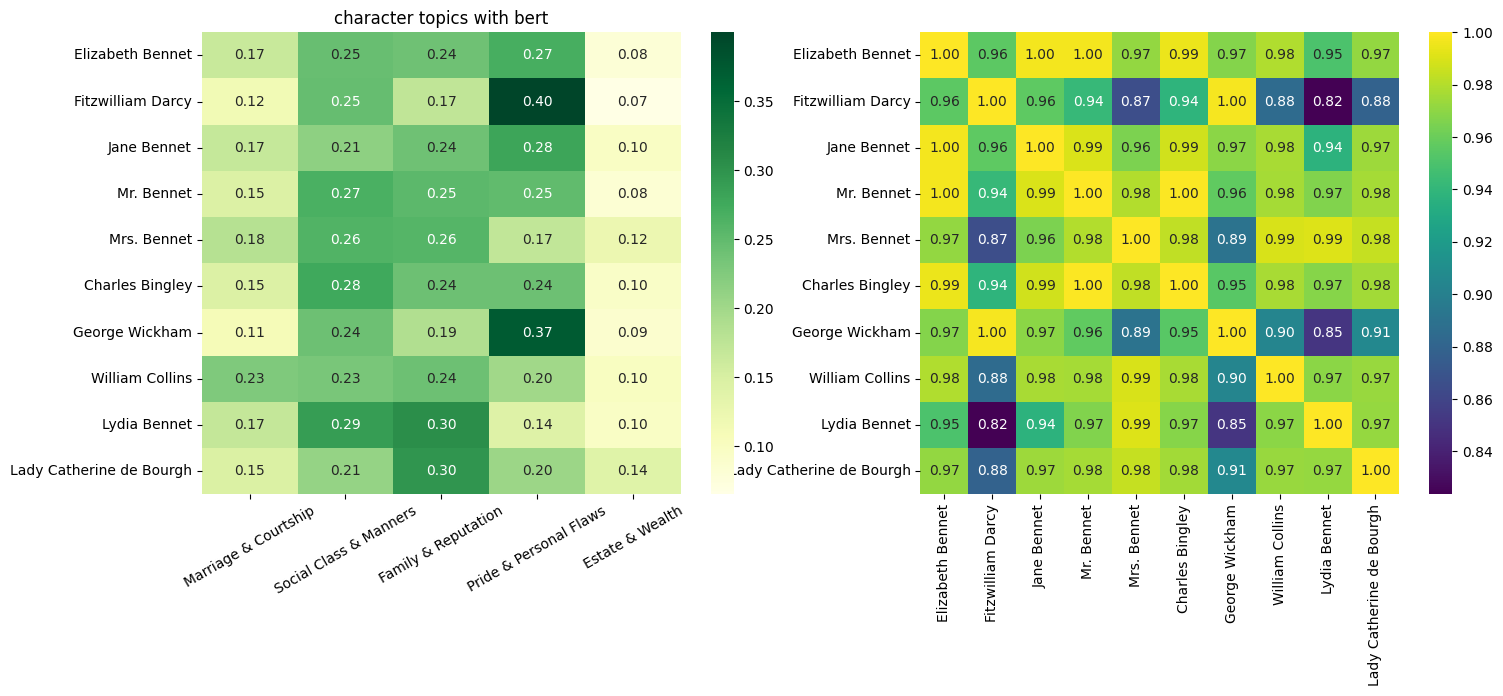

In [12]:
# task 7: compare topics using sentence-bert
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer

# load bert model
print("loading bert model")
llm_embedder = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')

# 5 main topics in the book
THEMATIC_TOPICS = {
    "Marriage & Courtship": "matrimony proposal wedding engagement courtship husband wife affection romance",
    "Social Class & Manners": "gentility etiquette rank status civility pride prejudice decorum hierarchy",
    "Family & Reputation": "daughters scandal honor sisters mother father duty propriety disgrace",
    "Pride & Personal Flaws": "arrogance vanity conceit esteem opinion insult resentment character judgement",
    "Estate & Wealth": "fortune estate inheritance income living pounds property patroness parish"
}

topic_labels = list(THEMATIC_TOPICS.keys())
topic_descriptions = list(THEMATIC_TOPICS.values())

# turn topics into vectors
topic_embeddings = llm_embedder.encode(topic_descriptions, convert_to_numpy=True)

# check how close each character is to each topic
char_llm_distributions = []

for char in valid_characters:
    dialogues = character_dialogues[char]

    # turn spoken lines into vectors
    char_speech_embeddings = llm_embedder.encode(dialogues, convert_to_numpy=True, batch_size=32)

    # find middle point for the character
    char_centroid = np.mean(char_speech_embeddings, axis=0, keepdims=True)

    # compare character lines to the 5 topics
    sims = cosine_similarity(char_centroid, topic_embeddings)[0]

    # scale scores to sum to 1
    exp_sims = np.exp(sims * 5)
    topic_dist = exp_sims / np.sum(exp_sims)
    char_llm_distributions.append(topic_dist)

# table of topic scores per character
df_char_llm_topics = pd.DataFrame(char_llm_distributions, index=valid_characters, columns=topic_labels)
df_char_llm_topics.to_csv("../data/processed/task7_llm_topic_distributions.csv")

# compare how similar characters are to each other
llm_sim_matrix = cosine_similarity(char_llm_distributions)
df_llm_sim = pd.DataFrame(llm_sim_matrix, index=valid_characters, columns=valid_characters)
df_llm_sim.to_csv("../data/processed/task7_llm_pairwise_similarity.csv")

# make 2 heatmaps
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(17, 6))

# plot topic shares
sns.heatmap(df_char_llm_topics, annot=True, cmap="YlGn", fmt=".2f", ax=axes[0], cbar=True)
axes[0].set_title("character topics with bert", fontsize=12)
axes[0].tick_params(axis='x', rotation=30)

# plot similarity between characters
sns.heatmap(df_llm_sim, annot=True, cmap="viridis", fmt=".2f", ax=axes[1], cbar=True)
axes

correlation between lda and bert scores:
 - pearson: 0.0653
 - spearman: -0.3565



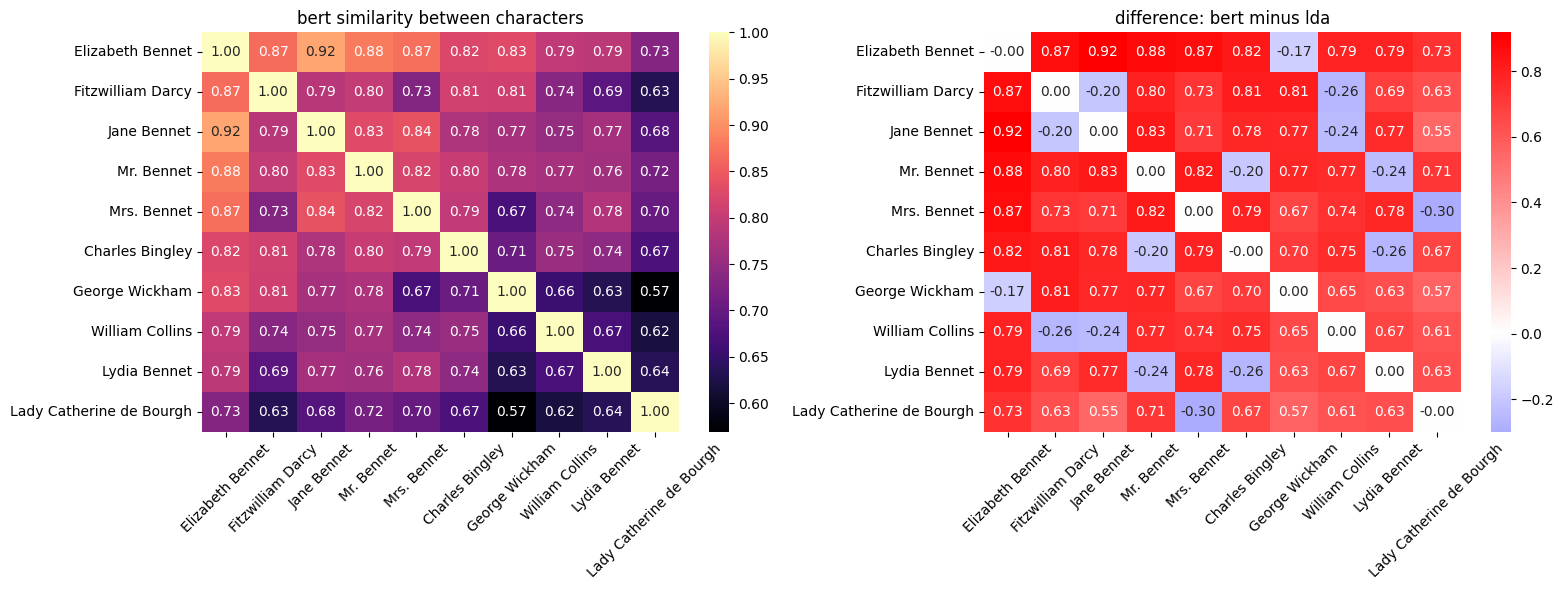

bert similarity table:


,Elizabeth Bennet,Fitzwilliam Darcy,Jane Bennet,Mr. Bennet,Mrs. Bennet,Charles Bingley,George Wickham,William Collins,Lydia Bennet,Lady Catherine de Bourgh
Elizabeth Bennet,1.000000,0.868098,0.918756,0.881549,0.868876,0.824581,0.828575,0.793977,0.790844,0.733182
Fitzwilliam Darcy,0.868098,1.000000,0.787829,0.798859,0.729221,0.811743,0.811070,0.737103,0.690172,0.634132
Jane Bennet,0.918756,0.787829,1.000000,0.828377,0.838595,0.776862,0.768684,0.749343,0.766689,0.682591
Mr. Bennet,0.881549,0.798859,0.828377,1.000000,0.819415,0.803101,0.775595,0.768686,0.763057,0.718752
Mrs. Bennet,0.868876,0.729221,0.838595,0.819415,1.000000,0.793893,0.670533,0.743538,0.780068,0.701445
Charles Bingley,0.824581,0.811743,0.776862,0.803101,0.793893,1.000000,0.705426,0.754469,0.743989,0.672446
George Wickham,0.828575,0.811070,0.768684,0.775595,0.670533,0.705426,1.000000,0.655383,0.632397,0.569180
William Collins,0.793977,0.737103,0.749343,0.768686,0.743538,0.754469,0.655383,1.000000,0.671359,0.618243
Lydia Bennet,0.790844,0.690172,0.766689,0.763057,0.780068,0.743989,0.632397,0.671359,1.000000,0.635820
Lady Catherine de Bourgh,0.733182,0.634132,0.682591,0.718752,0.701445,0.672446,0.569180,0.618243,0.635820,1.000000


In [13]:
# task 8: make sentence vectors with bert and compare with lda
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer

# make one average vector for all lines of each character
bert_char_embeddings = []

for char in valid_characters:
    dialogues = character_dialogues[char]

    # turn lines into vectors
    utterance_embeddings = llm_embedder.encode(dialogues, convert_to_numpy=True, show_progress_bar=False)

    # average the vectors
    char_embedding = np.mean(utterance_embeddings, axis=0)
    bert_char_embeddings.append(char_embedding)

bert_char_embeddings = np.array(bert_char_embeddings)

# compare all characters using bert vectors
bert_sim_matrix = cosine_similarity(bert_char_embeddings)
df_bert_sim = pd.DataFrame(bert_sim_matrix, index=valid_characters, columns=valid_characters)
df_bert_sim.to_csv("../data/processed/task8_bert_pairwise_similarity.csv")

# check how close lda and bert scores are
n_chars = len(valid_characters)
triu_indices = np.triu_indices(n_chars, k=1)

lda_sim_values = lda_sim_matrix[triu_indices]
bert_sim_values = bert_sim_matrix[triu_indices]

# test relationship between the two results
from scipy.stats import pearsonr, spearmanr
pearson_corr, _ = pearsonr(lda_sim_values, bert_sim_values)
spearman_corr, _ = spearmanr(lda_sim_values, bert_sim_values)

print("correlation between lda and bert scores:")
print(f" - pearson: {pearson_corr:.4f}")
print(f" - spearman: {spearman_corr:.4f}\n")

# make 2 heatmaps
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 6))

# plot bert similarity
sns.heatmap(df_bert_sim, annot=True, cmap="magma", fmt=".2f", ax=axes[0], cbar=True)
axes[0].set_title("bert similarity between characters", fontsize=12)
axes[0].tick_params(axis='x', rotation=45)

# plot bert minus lda
diff_matrix = bert_sim_matrix - lda_sim_matrix
df_diff = pd.DataFrame(diff_matrix, index=valid_characters, columns=valid_characters)

sns.heatmap(df_diff, annot=True, cmap="bwr", center=0, fmt=".2f", ax=axes[1], cbar=True)
axes[1].set_title("difference: bert minus lda", fontsize=12)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig("../figures/task8_bert_vs_lda_analysis.png", dpi=300)
plt.show()

print("bert similarity table:")
display(df_bert_sim)

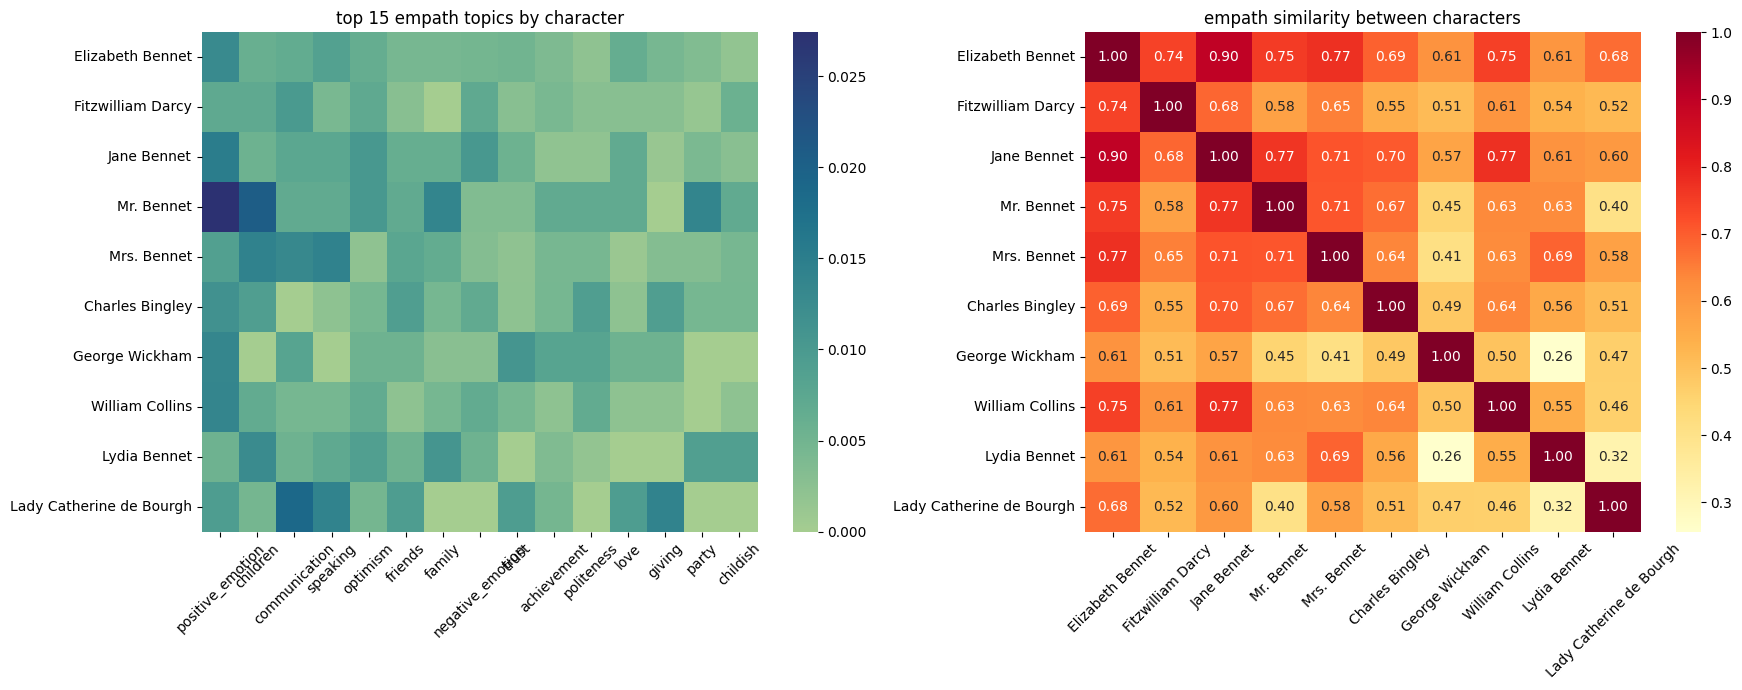

top 15 topics table:


,positive_emotion,children,communication,speaking,optimism,friends,family,negative_emotion,trust,achievement,politeness,love,giving,party,childish
Elizabeth Bennet,0.012767,0.006064,0.006703,0.008618,0.006384,0.004469,0.004469,0.004788,0.005107,0.003830,0.002234,0.006384,0.004469,0.003511,0.001915
Fitzwilliam Darcy,0.007112,0.007112,0.009957,0.004267,0.007112,0.002845,0.000000,0.007112,0.002845,0.004267,0.002845,0.002845,0.002845,0.001422,0.005690
Jane Bennet,0.015183,0.005521,0.007591,0.007591,0.010352,0.006211,0.006211,0.010352,0.005521,0.002070,0.002070,0.006901,0.001380,0.004141,0.002761
Mr. Bennet,0.027397,0.020548,0.006849,0.006849,0.010274,0.006849,0.013699,0.003425,0.003425,0.006849,0.006849,0.006849,0.000000,0.013699,0.006849
Mrs. Bennet,0.008811,0.014317,0.013216,0.014317,0.002203,0.007709,0.006608,0.003304,0.002203,0.004405,0.004405,0.001101,0.003304,0.003304,0.004405
Charles Bingley,0.011468,0.009174,0.000000,0.002294,0.004587,0.009174,0.004587,0.006881,0.002294,0.004587,0.009174,0.002294,0.009174,0.004587,0.004587
George Wickham,0.013514,0.000000,0.008108,0.000000,0.005405,0.005405,0.002703,0.002703,0.010811,0.008108,0.008108,0.005405,0.005405,0.000000,0.000000
William Collins,0.013667,0.006834,0.004556,0.004556,0.006834,0.002278,0.004556,0.006834,0.004556,0.002278,0.006834,0.002278,0.002278,0.000000,0.002278
Lydia Bennet,0.005367,0.012522,0.005367,0.007156,0.008945,0.005367,0.010733,0.005367,0.000000,0.003578,0.001789,0.000000,0.000000,0.008945,0.008945
Lady Catherine de Bourgh,0.009390,0.004695,0.018779,0.014085,0.004695,0.009390,0.000000,0.000000,0.009390,0.004695,0.000000,0.009390,0.014085,0.000000,0.000000



similarity table:


,Elizabeth Bennet,Fitzwilliam Darcy,Jane Bennet,Mr. Bennet,Mrs. Bennet,Charles Bingley,George Wickham,William Collins,Lydia Bennet,Lady Catherine de Bourgh
Elizabeth Bennet,1.000000,0.741573,0.899305,0.753444,0.773858,0.692384,0.611722,0.746803,0.606842,0.675089
Fitzwilliam Darcy,0.741573,1.000000,0.684003,0.576254,0.646250,0.546898,0.512650,0.609268,0.536764,0.517915
Jane Bennet,0.899305,0.684003,1.000000,0.766142,0.713121,0.704029,0.570328,0.774174,0.612578,0.597886
Mr. Bennet,0.753444,0.576254,0.766142,1.000000,0.709493,0.672098,0.453212,0.631726,0.630997,0.404905
Mrs. Bennet,0.773858,0.646250,0.713121,0.709493,1.000000,0.637427,0.410329,0.628786,0.689468,0.576441
Charles Bingley,0.692384,0.546898,0.704029,0.672098,0.637427,1.000000,0.485625,0.637346,0.557176,0.513228
George Wickham,0.611722,0.512650,0.570328,0.453212,0.410329,0.485625,1.000000,0.495333,0.256240,0.466875
William Collins,0.746803,0.609268,0.774174,0.631726,0.628786,0.637346,0.495333,1.000000,0.548314,0.463410
Lydia Bennet,0.606842,0.536764,0.612578,0.630997,0.689468,0.557176,0.256240,0.548314,1.000000,0.321964
Lady Catherine de Bourgh,0.675089,0.517915,0.597886,0.404905,0.576441,0.513228,0.466875,0.463410,0.321964,1.000000


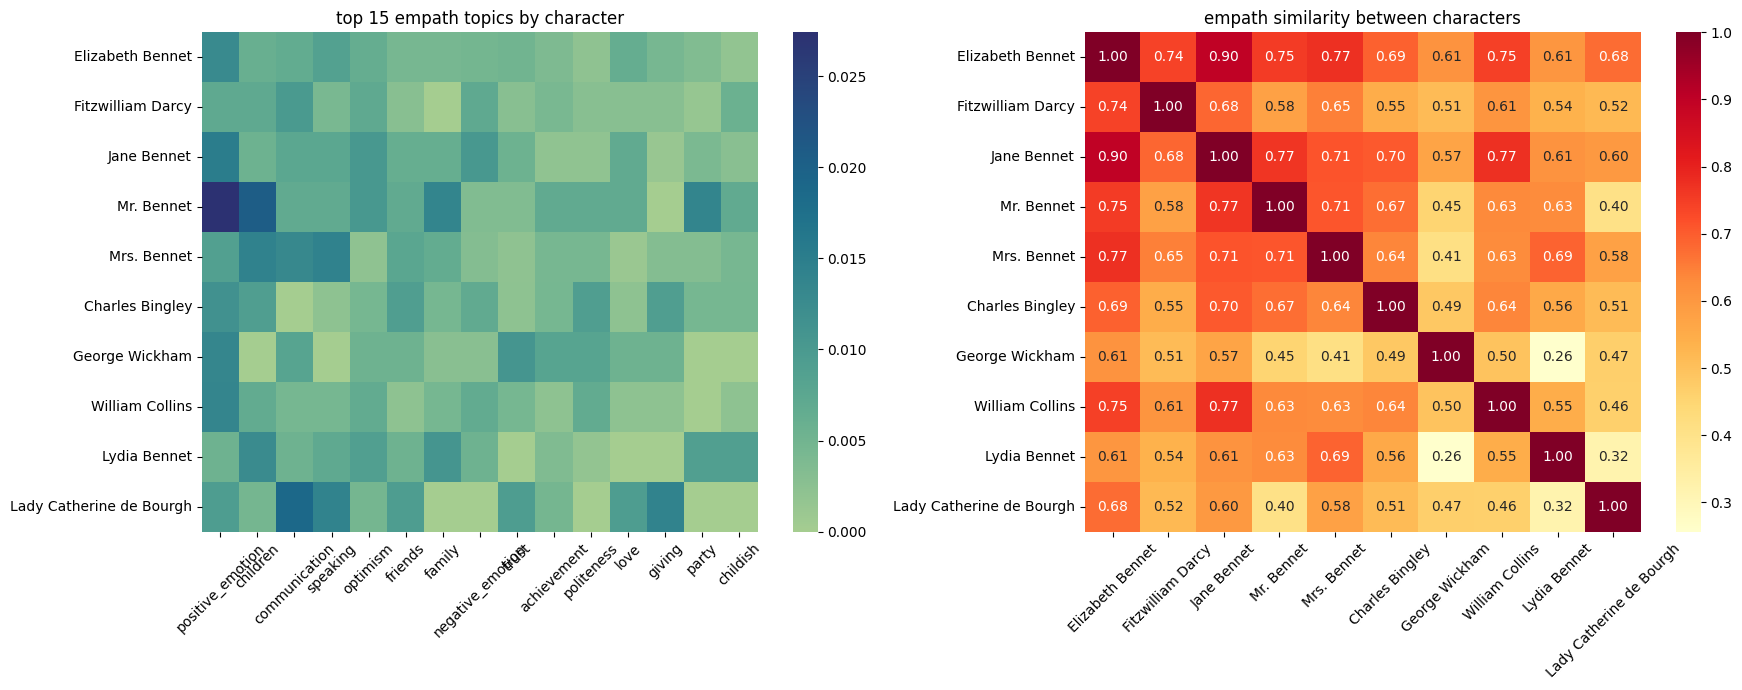

top 15 topics table:


,positive_emotion,children,communication,speaking,optimism,friends,family,negative_emotion,trust,achievement,politeness,love,giving,party,childish
Elizabeth Bennet,0.012767,0.006064,0.006703,0.008618,0.006384,0.004469,0.004469,0.004788,0.005107,0.003830,0.002234,0.006384,0.004469,0.003511,0.001915
Fitzwilliam Darcy,0.007112,0.007112,0.009957,0.004267,0.007112,0.002845,0.000000,0.007112,0.002845,0.004267,0.002845,0.002845,0.002845,0.001422,0.005690
Jane Bennet,0.015183,0.005521,0.007591,0.007591,0.010352,0.006211,0.006211,0.010352,0.005521,0.002070,0.002070,0.006901,0.001380,0.004141,0.002761
Mr. Bennet,0.027397,0.020548,0.006849,0.006849,0.010274,0.006849,0.013699,0.003425,0.003425,0.006849,0.006849,0.006849,0.000000,0.013699,0.006849
Mrs. Bennet,0.008811,0.014317,0.013216,0.014317,0.002203,0.007709,0.006608,0.003304,0.002203,0.004405,0.004405,0.001101,0.003304,0.003304,0.004405
Charles Bingley,0.011468,0.009174,0.000000,0.002294,0.004587,0.009174,0.004587,0.006881,0.002294,0.004587,0.009174,0.002294,0.009174,0.004587,0.004587
George Wickham,0.013514,0.000000,0.008108,0.000000,0.005405,0.005405,0.002703,0.002703,0.010811,0.008108,0.008108,0.005405,0.005405,0.000000,0.000000
William Collins,0.013667,0.006834,0.004556,0.004556,0.006834,0.002278,0.004556,0.006834,0.004556,0.002278,0.006834,0.002278,0.002278,0.000000,0.002278
Lydia Bennet,0.005367,0.012522,0.005367,0.007156,0.008945,0.005367,0.010733,0.005367,0.000000,0.003578,0.001789,0.000000,0.000000,0.008945,0.008945
Lady Catherine de Bourgh,0.009390,0.004695,0.018779,0.014085,0.004695,0.009390,0.000000,0.000000,0.009390,0.004695,0.000000,0.009390,0.014085,0.000000,0.000000



similarity table:


,Elizabeth Bennet,Fitzwilliam Darcy,Jane Bennet,Mr. Bennet,Mrs. Bennet,Charles Bingley,George Wickham,William Collins,Lydia Bennet,Lady Catherine de Bourgh
Elizabeth Bennet,1.000000,0.741573,0.899305,0.753444,0.773858,0.692384,0.611722,0.746803,0.606842,0.675089
Fitzwilliam Darcy,0.741573,1.000000,0.684003,0.576254,0.646250,0.546898,0.512650,0.609268,0.536764,0.517915
Jane Bennet,0.899305,0.684003,1.000000,0.766142,0.713121,0.704029,0.570328,0.774174,0.612578,0.597886
Mr. Bennet,0.753444,0.576254,0.766142,1.000000,0.709493,0.672098,0.453212,0.631726,0.630997,0.404905
Mrs. Bennet,0.773858,0.646250,0.713121,0.709493,1.000000,0.637427,0.410329,0.628786,0.689468,0.576441
Charles Bingley,0.692384,0.546898,0.704029,0.672098,0.637427,1.000000,0.485625,0.637346,0.557176,0.513228
George Wickham,0.611722,0.512650,0.570328,0.453212,0.410329,0.485625,1.000000,0.495333,0.256240,0.466875
William Collins,0.746803,0.609268,0.774174,0.631726,0.628786,0.637346,0.495333,1.000000,0.548314,0.463410
Lydia Bennet,0.606842,0.536764,0.612578,0.630997,0.689468,0.557176,0.256240,0.548314,1.000000,0.321964
Lady Catherine de Bourgh,0.675089,0.517915,0.597886,0.404905,0.576441,0.513228,0.466875,0.463410,0.321964,1.000000


In [14]:
# task 9: count empath topics and compare characters
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
from empath import Empath

# start empath tool
lexicon = Empath()

# get scores for each topic from spoken lines
empath_vectors = []
all_categories = None

for char in valid_characters:
    full_speech = " ".join(character_dialogues[char])

    # check word categories and divide by total words
    analysis = lexicon.analyze(full_speech, normalize=True)

    if analysis is None:
        analysis = {k: 0.0 for k in lexicon.cats.keys()}

    if all_categories is None:
        all_categories = sorted(list(analysis.keys()))

    vector = [analysis[cat] for cat in all_categories]
    empath_vectors.append(vector)

empath_matrix = np.array(empath_vectors)

# table of empath scores per character
df_empath_profiles = pd.DataFrame(empath_matrix, index=valid_characters, columns=all_categories)
df_empath_profiles.to_csv("../data/processed/task9_empath_category_profiles.csv")

# compare similarity using empath scores
empath_sim_matrix = cosine_similarity(empath_matrix)
df_empath_sim = pd.DataFrame(empath_sim_matrix, index=valid_characters, columns=valid_characters)
df_empath_sim.to_csv("../data/processed/task9_empath_pairwise_similarity.csv")

# find the 15 most used topics
active_categories = df_empath_profiles.mean(axis=0).sort_values(ascending=False).head(15).index.tolist()
df_top_cats = df_empath_profiles[active_categories]

# make 2 heatmaps
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(18, 7))

# plot top 15 topics
sns.heatmap(df_top_cats, annot=False, cmap="crest", ax=axes[0], cbar=True)
axes[0].set_title("top 15 empath topics by character", fontsize=12)
axes[0].tick_params(axis='x', rotation=45)

# plot similarity between characters
sns.heatmap(df_empath_sim, annot=True, cmap="YlOrRd", fmt=".2f", ax=axes[1], cbar=True)
axes[1].set_title("empath similarity between characters", fontsize=12)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig("../figures/task9_empath_analysis.png", dpi=300)
plt.show()

print("top 15 topics table:")
display(df_top_cats)

print("\nsimilarity table:")
display(df_empath_sim)# task 9: count empath topics and compare characters
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
from empath import Empath

# start empath tool
lexicon = Empath()

# get scores for each topic from spoken lines
empath_vectors = []
all_categories = None

for char in valid_characters:
    full_speech = " ".join(character_dialogues[char])

    # check word categories and divide by total words
    analysis = lexicon.analyze(full_speech, normalize=True)

    if analysis is None:
        analysis = {k: 0.0 for k in lexicon.cats.keys()}

    if all_categories is None:
        all_categories = sorted(list(analysis.keys()))

    vector = [analysis[cat] for cat in all_categories]
    empath_vectors.append(vector)

empath_matrix = np.array(empath_vectors)

# table of empath scores per character
df_empath_profiles = pd.DataFrame(empath_matrix, index=valid_characters, columns=all_categories)
df_empath_profiles.to_csv("../data/processed/task9_empath_category_profiles.csv")

# compare similarity using empath scores
empath_sim_matrix = cosine_similarity(empath_matrix)
df_empath_sim = pd.DataFrame(empath_sim_matrix, index=valid_characters, columns=valid_characters)
df_empath_sim.to_csv("../data/processed/task9_empath_pairwise_similarity.csv")

# find the 15 most used topics
active_categories = df_empath_profiles.mean(axis=0).sort_values(ascending=False).head(15).index.tolist()
df_top_cats = df_empath_profiles[active_categories]

# make 2 heatmaps
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(18, 7))

# plot top 15 topics
sns.heatmap(df_top_cats, annot=False, cmap="crest", ax=axes[0], cbar=True)
axes[0].set_title("top 15 empath topics by character", fontsize=12)
axes[0].tick_params(axis='x', rotation=45)

# plot similarity between characters
sns.heatmap(df_empath_sim, annot=True, cmap="YlOrRd", fmt=".2f", ax=axes[1], cbar=True)
axes[1].set_title("empath similarity between characters", fontsize=12)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig("../figures/task9_empath_analysis.png", dpi=300)
plt.show()

print("top 15 topics table:")
display(df_top_cats)

print("\nsimilarity table:")
display(df_empath_sim)

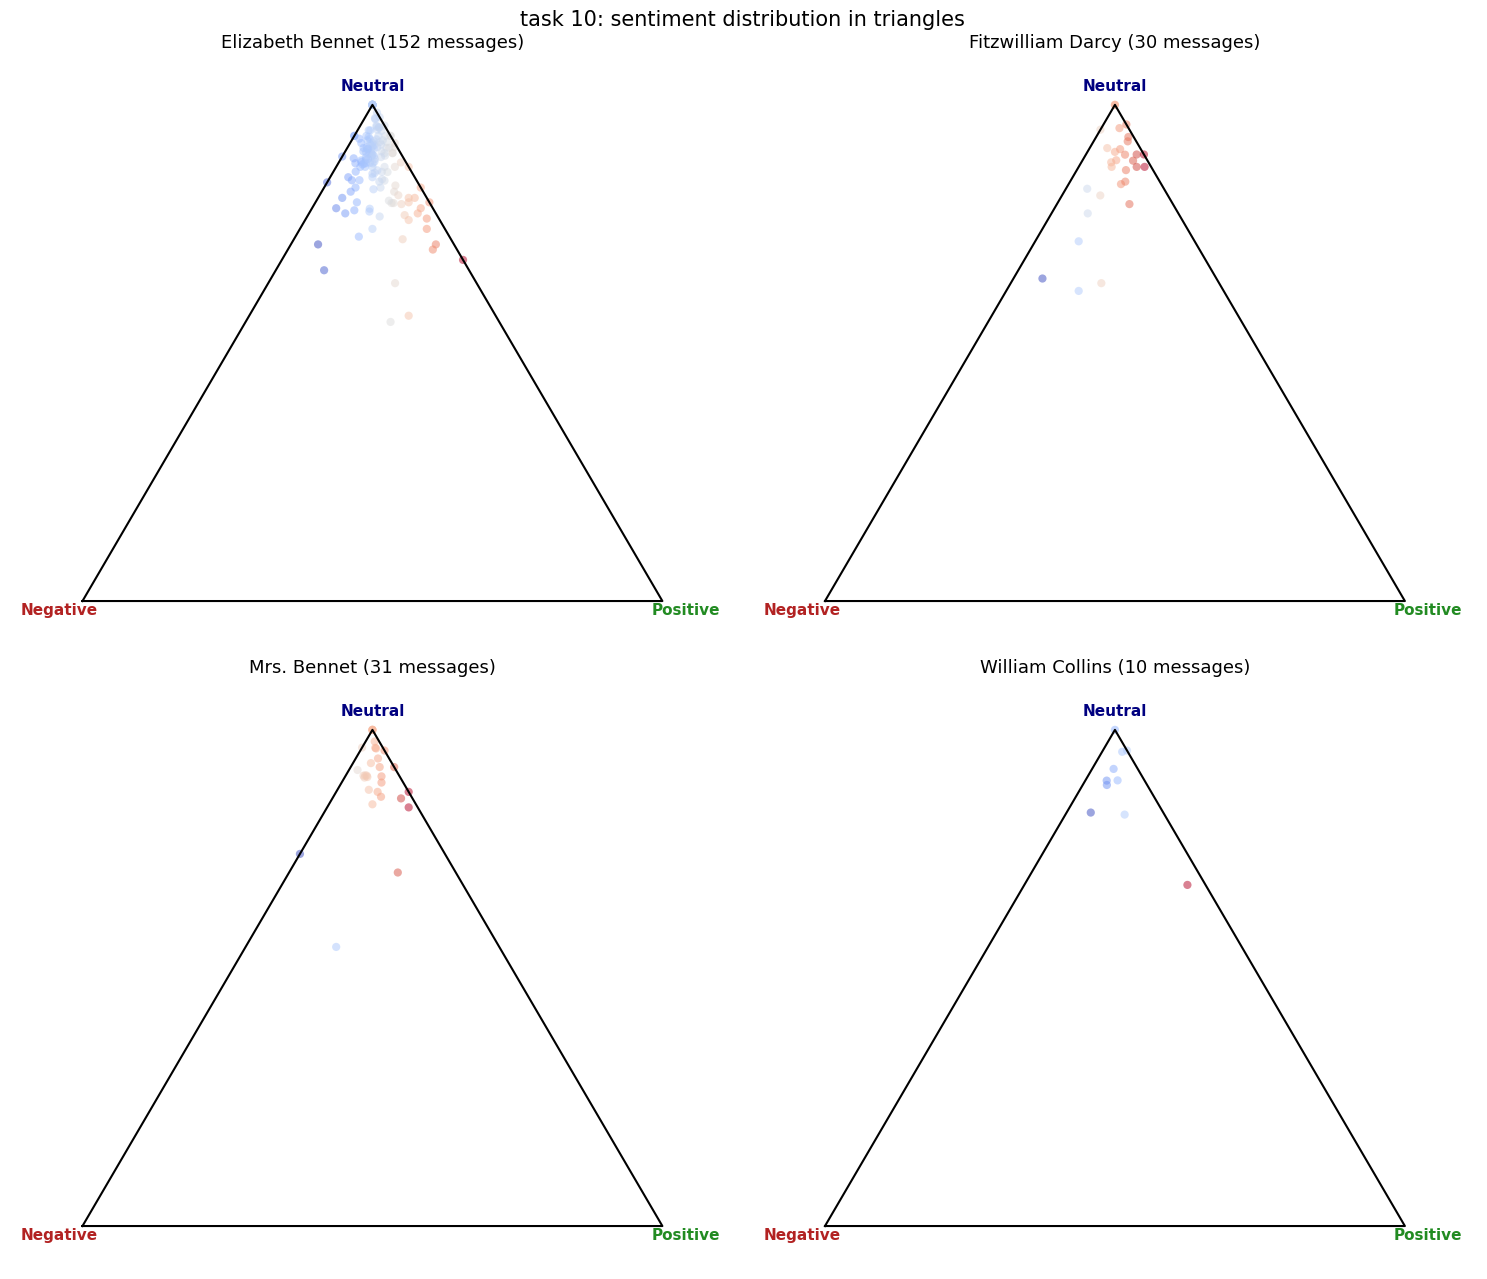

sentiment table:


,Character,Pos,Neg,Neu,Net Polarity (Pos - Neg)
0,Mr. Bennet,0.060761,0.038115,0.901124,0.022646
1,William Collins,0.067243,0.045732,0.887024,0.021511
2,Elizabeth Bennet,0.069656,0.051738,0.878606,0.017918
3,Charles Bingley,0.071172,0.054885,0.873943,0.016287
4,Jane Bennet,0.053327,0.048510,0.898163,0.004818
5,Mrs. Bennet,0.052571,0.048157,0.899272,0.004414
6,Lydia Bennet,0.042009,0.041407,0.916584,0.000602
7,Fitzwilliam Darcy,0.066860,0.071043,0.862097,-0.004183
8,George Wickham,0.055067,0.061935,0.882998,-0.006868
9,Lady Catherine de Bourgh,0.053461,0.075472,0.871068,-0.022011


In [16]:
# task 10: get sentiment scores for lines and plot in triangles
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from nltk.corpus import sentiwordnet as swn
from nltk.corpus import wordnet as wn
from nltk.tokenize import word_tokenize
from nltk import pos_tag

# match pos tag to wordnet format
def get_wordnet_pos(tag):
    if tag.startswith('J'):
        return wn.ADJ
    elif tag.startswith('V'):
        return wn.VERB
    elif tag.startswith('N'):
        return wn.NOUN
    elif tag.startswith('R'):
        return wn.ADV
    else:
        return None

# score one line using sentiwordnet
def score_utterance(text):
    tokens = [w.lower() for w in word_tokenize(text) if w.isalnum()]
    if not tokens:
        return 0.0, 0.0, 1.0

    tagged = pos_tag(tokens)
    pos_scores = []
    neg_scores = []

    for word, tag in tagged:
        wn_tag = get_wordnet_pos(tag)
        if not wn_tag:
            pos_scores.append(0.0)
            neg_scores.append(0.0)
            continue

        synsets = list(swn.senti_synsets(word, wn_tag))
        if synsets:
            swn_synset = synsets[0]
            pos_scores.append(swn_synset.pos_score())
            neg_scores.append(swn_synset.neg_score())
        else:
            pos_scores.append(0.0)
            neg_scores.append(0.0)

    avg_pos = np.mean(pos_scores)
    avg_neg = np.mean(neg_scores)
    avg_neu = max(0.0, 1.0 - (avg_pos + avg_neg))

    # normalize so values sum to 1
    total = avg_pos + avg_neg + avg_neu
    if total == 0:
        return 0.0, 0.0, 1.0
    return avg_pos / total, avg_neg / total, avg_neu / total

# score all lines for each character
message_sentiment_records = []

for char in valid_characters:
    quotes = character_dialogues[char]
    for quote in quotes:
        if len(quote.split()) >= 3:
            p_pos, p_neg, p_neu = score_utterance(quote)
            message_sentiment_records.append({
                "Character": char,
                "Quote": quote,
                "Pos": p_pos,
                "Neg": p_neg,
                "Neu": p_neu
            })

df_messages = pd.DataFrame(message_sentiment_records)
df_messages.to_csv("../data/processed/task10_character_messages_sentiment.csv", index=False)

# change pos neg neu scores to x y points for triangle plot
def ternary_to_cartesian(pos, neg, neu):
    x = pos - neg
    y = neu * np.sqrt(3)
    return x, y

# make 4 triangle plots
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 13))
axes = axes.flatten()

# pick 4 characters to show
target_chars = ["Elizabeth Bennet", "Fitzwilliam Darcy", "Mrs. Bennet", "William Collins"]

for idx, char in enumerate(target_chars):
    ax = axes[idx]
    sub = df_messages[df_messages["Character"] == char]

    # draw triangle borders
    triangle_x = [-1, 1, 0, -1]
    triangle_y = [0, 0, np.sqrt(3), 0]
    ax.plot(triangle_x, triangle_y, 'k-', lw=1.5)

    # place points inside triangle
    xs, ys = ternary_to_cartesian(sub["Pos"].values, sub["Neg"].values, sub["Neu"].values)

    scatter = ax.scatter(xs, ys, alpha=0.5, edgecolors='none', c=sub["Pos"] - sub["Neg"], cmap="coolwarm", s=35)

    # corner labels
    ax.text(-1.08, -0.05, "Negative", fontsize=11, fontweight="bold", ha="center", color="firebrick")
    ax.text(1.08, -0.05, "Positive", fontsize=11, fontweight="bold", ha="center", color="forestgreen")
    ax.text(0, np.sqrt(3) + 0.05, "Neutral", fontsize=11, fontweight="bold", ha="center", color="navy")

    ax.set_title(f"{char} ({len(sub)} messages)", fontsize=13, pad=10)
    ax.set_xlim(-1.25, 1.25)
    ax.set_ylim(-0.15, np.sqrt(3) + 0.15)
    ax.axis("off")

plt.suptitle("task 10: sentiment distribution in triangles", fontsize=15, y=0.98)
plt.tight_layout()
plt.savefig("../figures/task10_sentiwordnet_triangles.png", dpi=300)
plt.show()

# average sentiment for each character
df_char_sent_summary = df_messages.groupby("Character")[["Pos", "Neg", "Neu"]].mean().reset_index()
df_char_sent_summary["Net Polarity (Pos - Neg)"] = df_char_sent_summary["Pos"] - df_char_sent_summary["Neg"]
df_char_sent_summary = df_char_sent_summary.sort_values(by="Net Polarity (Pos - Neg)", ascending=False).reset_index(drop=True)
df_char_sent_summary.to_csv("../data/processed/task10_character_sentiment_summary.csv", index=False)

print("sentiment table:")
display(df_char_sent_summary)